In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [ ]:
FILE_PATH = "../raw_data/spotify-tracks-dataset.xlsb"

print("Loading dataset...")

df = pd.read_excel(FILE_PATH, engine="pyxlsb")

print("Dataset loaded:", df.shape)

csv_path = "../raw_data/spotify-tracks-dataset.csv"
df.to_csv(csv_path, index=False)


Loading dataset...
Dataset loaded: (550622, 23)
CSV saved: ../raw_data/spotify-tracks-dataset.csv


In [4]:
TRACK_COL = "name"
ARTIST_COL = "artists"
YEAR_COL = "year"
GENRE_COL = "genre"
POPULARITY_COL = "popularity"
ARTIST_POP_COL = "avg_artist_popularity"

In [5]:
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 550622 entries, 0 to 550621
Data columns (total 23 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      550622 non-null  str    
 1   name                    550619 non-null  object 
 2   album_name              550602 non-null  object 
 3   artists                 550622 non-null  str    
 4   danceability            550622 non-null  float64
 5   energy                  550622 non-null  float64
 6   key                     550622 non-null  int64  
 7   loudness                550622 non-null  float64
 8   mode                    550622 non-null  int64  
 9   speechiness             550622 non-null  float64
 10  acousticness            550622 non-null  float64
 11  instrumentalness        550622 non-null  float64
 12  liveness                550622 non-null  float64
 13  valence                 550622 non-null  float64
 14  tempo                   550622 

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,year,popularity,total_artist_followers,avg_artist_popularity
count,550622.000000,550622.000000,550622.000000,550622.000000,550622.000000,550622.000000,550622.000000,550622.000000,550622.000000,550622.000000,550622.000000,5.506220e+05,550622.000000,550622.000000,5.506220e+05,550622.000000
mean,0.527173,0.671389,5.275487,-7.877679,0.667360,0.085574,0.243174,0.107573,0.224043,0.464568,122.815094,2.374116e+05,2007.144742,17.575954,2.533411e+06,48.076930
std,0.172603,0.245591,3.558157,3.858865,0.471159,0.093337,0.307418,0.239932,0.196800,0.249094,29.453634,9.555273e+04,13.575992,17.457960,9.227678e+06,19.154401
min,0.045500,0.000020,0.000000,-44.868000,0.000000,0.021900,0.000000,0.000000,0.006730,0.000000,30.946000,1.502700e+04,1900.000000,0.000000,0.000000e+00,0.000000
25%,0.408000,0.496000,2.000000,-9.907000,0.000000,0.035000,0.003650,0.000000,0.099600,0.259000,99.978000,1.840400e+05,2002.000000,0.000000,5.510225e+04,35.000000
50%,0.530000,0.716000,5.000000,-7.038000,1.000000,0.049700,0.075500,0.000185,0.141000,0.447000,121.729000,2.230000e+05,2010.000000,14.000000,2.693830e+05,49.000000
75%,0.651000,0.886000,8.000000,-5.095000,1.000000,0.092200,0.432000,0.032200,0.294000,0.660000,140.938000,2.707830e+05,2017.000000,30.000000,1.354562e+06,62.000000
max,0.988000,1.000000,11.000000,0.000000,1.000000,0.966000,0.996000,0.998000,1.000000,0.998000,245.941000,4.995315e+06,2025.000000,98.000000,2.951819e+08,100.000000


In [6]:
df.isnull().sum().sort_values(ascending=False)

album_name                20
name                       3
id                         0
artists                    0
danceability               0
energy                     0
key                        0
loudness                   0
mode                       0
speechiness                0
acousticness               0
instrumentalness           0
liveness                   0
valence                    0
tempo                      0
duration_ms                0
year                       0
genre                      0
popularity                 0
total_artist_followers     0
avg_artist_popularity      0
artist_ids                 0
niche_genres               0
dtype: int64

count    550622.000000
mean         17.575954
std          17.457960
min           0.000000
25%           0.000000
50%          14.000000
75%          30.000000
max          98.000000
Name: popularity, dtype: float64
Zero popularity count: 148778
Percent: 27.01998830413605


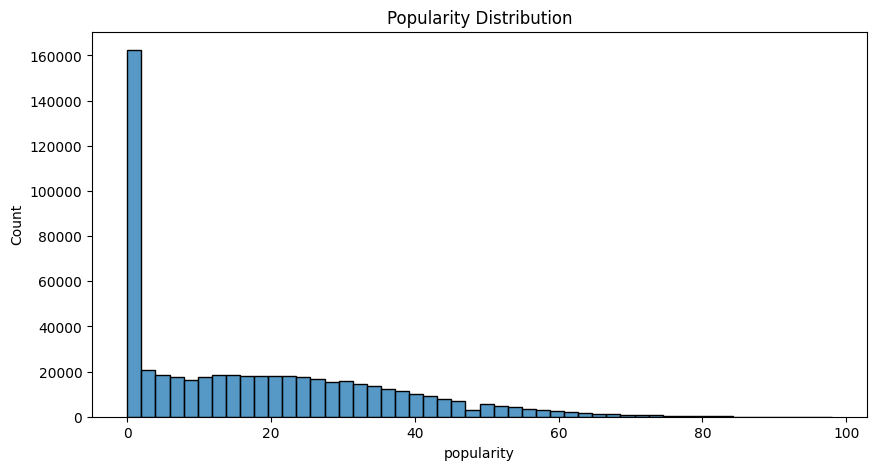

In [7]:
print(df[POPULARITY_COL].describe())

zero_pop = (df[POPULARITY_COL] == 0).sum()

print("Zero popularity count:", zero_pop)
print("Percent:", zero_pop / len(df) * 100)

plt.figure(figsize=(10,5))
sns.histplot(df[POPULARITY_COL], bins=50)
plt.title("Popularity Distribution")
plt.show()

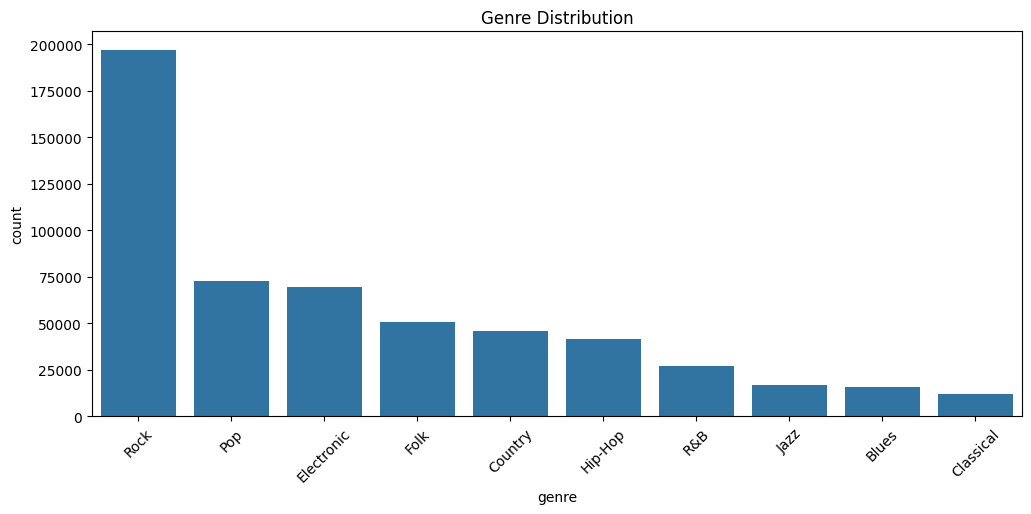

In [8]:
plt.figure(figsize=(12,5))
sns.countplot(
    data=df,
    x=GENRE_COL,
    order=df[GENRE_COL].value_counts().index
)
plt.xticks(rotation=45)
plt.title("Genre Distribution")
plt.show()

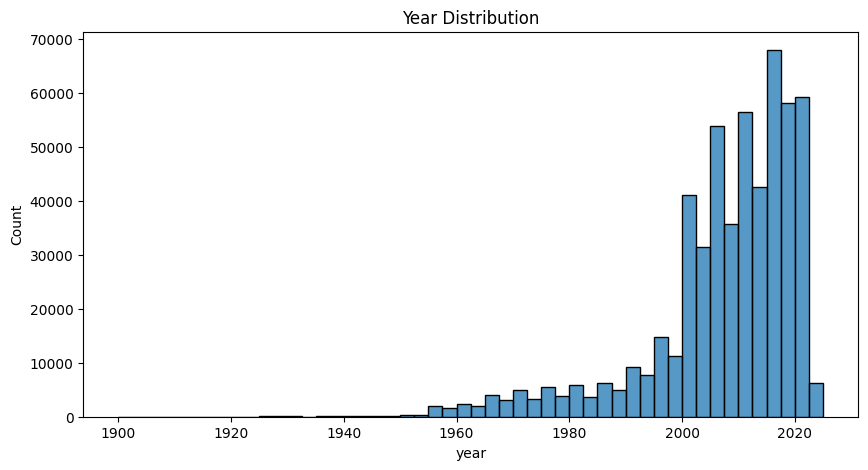

In [9]:
plt.figure(figsize=(10,5))
sns.histplot(df[YEAR_COL], bins=50)
plt.title("Year Distribution")
plt.show()

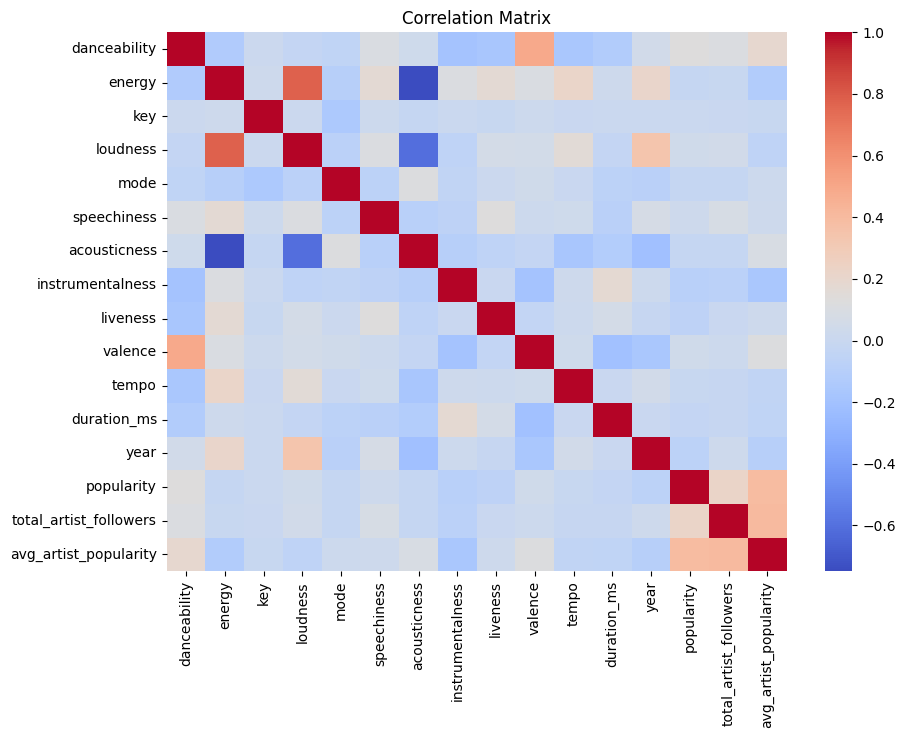

In [10]:
num_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,7))
sns.heatmap(num_cols.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [11]:
df["_track_artist"] = (
    df[TRACK_COL].astype(str).str.lower().str.strip()
    + " - " +
    df[ARTIST_COL].astype(str).str.lower().str.strip()
)

dupes = df.duplicated("_track_artist").sum()

print("Duplicate songs:", dupes)

Duplicate songs: 77335


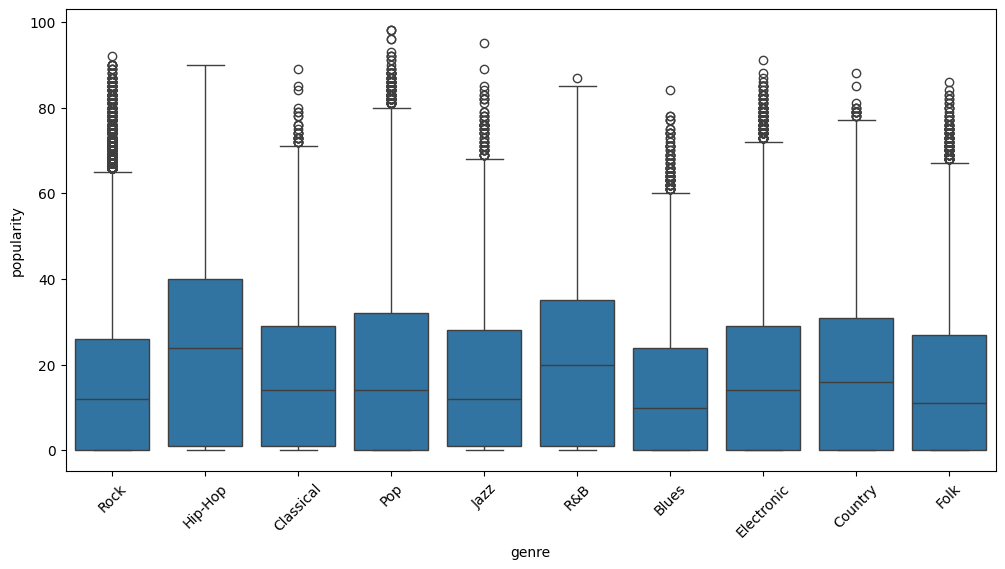

In [13]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="genre", y="popularity")
plt.xticks(rotation=45)
plt.show()

In [14]:
df.groupby("genre")["popularity"].mean().sort_values(ascending=False)

genre
Hip-Hop       24.578896
R&B           21.323700
Pop           18.827127
Country       18.486197
Classical     17.554095
Electronic    17.180790
Jazz          16.448383
Rock          15.943556
Folk          15.527801
Blues         14.165373
Name: popularity, dtype: float64

In [15]:
df["genre"].value_counts()

genre
Rock          197168
Pop            72539
Electronic     69755
Folk           50843
Country        46076
Hip-Hop        41745
R&B            27337
Jazz           17010
Blues          15976
Classical      12173
Name: count, dtype: int64